# Airline Passenger Satisfaction Analysis

## Project Introduction

This project focuses on the Airline Passenger Satisfaction dataset. The dataset contains information about airline passengers, their flight experience, and their overall satisfaction level.

The main goal of this project is to analyze the data, identify factors that affect passenger satisfaction, and build a Machine Learning model capable of predicting whether a passenger is satisfied or dissatisfied.

The project will include data exploration, data cleaning, feature analysis, data preprocessing, model building, and model evaluation.

---

# Step 1 - Initial Dataset Exploration

In this stage, the dataset is loaded using the Pandas library and a preliminary exploration of the data is performed.

The first five rows of the dataset are displayed, followed by an examination of the dataset dimensions and data types.

This step is important because it helps us understand the structure of the dataset and become familiar with the available features before performing further analysis and preprocessing.

In [11]:
# ==========================================
# Step 1: Data Loading and Initial Exploration
# ==========================================

print("=== Starting Step 1: Data Loading ===\n")

import pandas as pd

# 1. Loading the dataset
df = pd.read_csv('train.csv')

# 2. Displaying the first 5 rows to inspect the data
print("--- The first 5 rows of the dataset ---")
display(df.head())

# 3. Checking data structure (shape)
print("\n--- Data structure (rows, columns) ---")
print(df.shape)

# 4. Checking general information and data types
print("\n--- General information about columns and data types ---")
df.info()

=== Starting Step 1: Data Loading ===

--- The first 5 rows of the dataset ---


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied



--- Data structure (rows, columns) ---
(103904, 25)

--- General information about columns and data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64 

# Step 2 - Exploratory Data Analysis (EDA)

## Overview

After becoming familiar with the dataset structure, the next step is to perform an Exploratory Data Analysis (EDA).

The purpose of this stage is to gain a deeper understanding of the data by examining numerical and categorical features, reviewing basic statistical measures, and identifying potential data quality issues.

The analysis includes:

* Identifying numerical and categorical columns.
* Examining descriptive statistics such as mean, median, minimum, and maximum values.
* Detecting missing values in the dataset.
* Identifying unusual values or potential outliers.

Understanding the data at this stage is essential for making informed decisions during data preprocessing and model development.

In [12]:
# ==========================================
# Step 2: Feature Types and Statistical Summary
# ==========================================

print("=== Starting Step 2: Data Summary ===\n")

# 1. Separating columns by data type (Numerical vs Categorical)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("=== COLUMN TYPES IN DATASET ===")
print(f"Numerical columns ({len(num_cols)}): {num_cols}\n")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

# 2. Generating statistical summary for numerical features
print("=== STATISTICAL SUMMARY FOR NUMERICAL COLUMNS ===")
display(df[num_cols].describe().T)
print("\n")

# 3. Checking for missing values (NULLs)
print("=== CHECKING FOR MISSING VALUES (NULLs) ===")
missing_values = df.isnull().sum()
missing_only = missing_values[missing_values > 0]

if len(missing_only) == 0:
    print("Great! There are no missing values in this dataset.")
else:
    print("Columns with missing values and their respective counts:")
    print(missing_only)

=== Starting Step 2: Data Summary ===

=== COLUMN TYPES IN DATASET ===
Numerical columns (20): ['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical columns (5): ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

=== STATISTICAL SUMMARY FOR NUMERICAL COLUMNS ===


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0




=== CHECKING FOR MISSING VALUES (NULLs) ===
Columns with missing values and their respective counts:
Arrival Delay in Minutes    310
dtype: int64


# Step 3 - Data Visualization

## Overview

Data visualization is an essential part of the data analysis process. While statistical summaries provide numerical insights, visualizations help reveal patterns, trends, relationships, and anomalies that may not be immediately apparent from tables alone.

In this stage, several visualizations are created using the Matplotlib and Seaborn libraries in order to better understand the Airline Passenger Satisfaction dataset.

The analysis includes:

* A histogram showing the distribution of passenger ages.
* A comparison of average flight distance across different travel classes.
* A correlation heatmap illustrating relationships between numerical variables.

Each visualization includes a title, axis labels, and a brief interpretation of the key findings.

Understanding these patterns helps identify important factors that may influence passenger satisfaction and provides valuable insights for the machine learning phase of the project.

=== Starting Step 3: Data Visualization ===



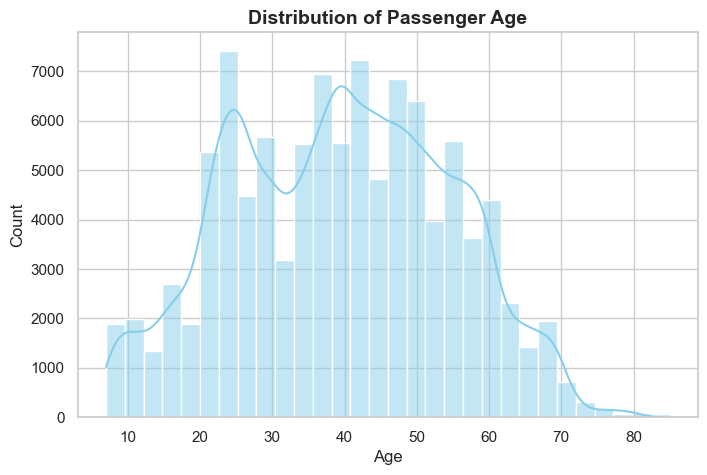

Graph 1 Insights:
The histogram shows the age distribution of the surveyed airline passengers.
We can observe that the majority of passengers are concentrated between the ages of 20 and 50,
with a noticeable peak around the late 30s and early 40s.




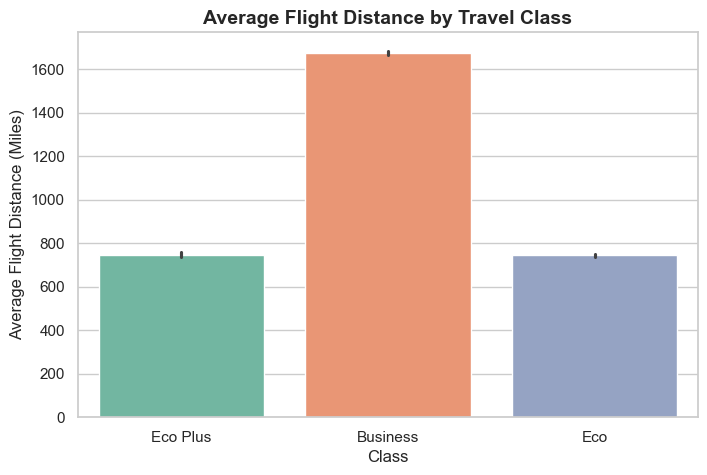

Graph 2 Insights:
This bar plot compares the average flight distance across different travel classes (Business, Eco, Eco Plus).
It clearly demonstrates that passengers in Business class tend to fly significantly longer distances 
on average compared to passengers traveling in Eco or Eco Plus classes.




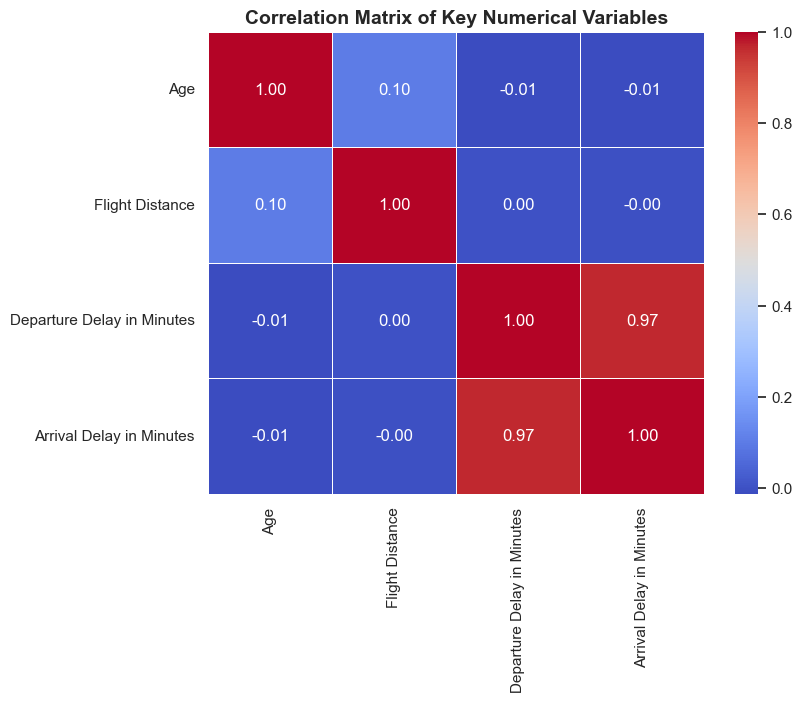

Graph 3 Insights:
The heatmap illustrates the linear relationships between select numerical features.
As expected, there is an extremely strong positive correlation (close to 1.00) between 
Departure Delay and Arrival Delay. Other variables, like Age and Flight Distance, 
show almost no linear correlation with each other.


In [13]:
# ==========================================
# Step 3: Data Visualization and Insights
# ==========================================

print("=== Starting Step 3: Data Visualization ===\n")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Graph 1: Histogram - Distribution of Passenger Age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', kde=True, color='skyblue', bins=30)
plt.title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("""Graph 1 Insights:
The histogram shows the age distribution of the surveyed airline passengers.
We can observe that the majority of passengers are concentrated between the ages of 20 and 50,
with a noticeable peak around the late 30s and early 40s.""")
print("\n")

# 2. Graph 2: Bar Plot - Flight Distance by Class
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Class', y='Flight Distance', estimator='mean', hue='Class', palette='Set2', legend=False)
plt.title('Average Flight Distance by Travel Class', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Average Flight Distance (Miles)', fontsize=12)
plt.show()

print("""Graph 2 Insights:
This bar plot compares the average flight distance across different travel classes (Business, Eco, Eco Plus).
It clearly demonstrates that passengers in Business class tend to fly significantly longer distances 
on average compared to passengers traveling in Eco or Eco Plus classes.""")
print("\n")

# 3. Graph 3: Heatmap - Correlation Matrix of Key Numerical Variables
key_num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
corr_matrix = df[key_num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Numerical Variables', fontsize=14, fontweight='bold')
plt.show()

print("""Graph 3 Insights:
The heatmap illustrates the linear relationships between select numerical features.
As expected, there is an extremely strong positive correlation (close to 1.00) between 
Departure Delay and Arrival Delay. Other variables, like Age and Flight Distance, 
show almost no linear correlation with each other.""")

# Step 4 - Data Preprocessing and Cleaning

## Overview

Before building a Machine Learning model, the dataset must be cleaned and prepared. Raw data often contains missing values, categorical variables, and irrelevant features that can negatively affect model performance.

The purpose of this stage is to transform the dataset into a format suitable for machine learning algorithms.

The preprocessing process includes:

* Handling missing values by replacing them with appropriate statistical values.
* Converting categorical variables into numerical representations using encoding techniques.
* Creating new features through feature engineering to provide additional information to the model.
* Removing unnecessary columns that do not contribute to prediction.

### Actions Performed

1. Missing values in the **Arrival Delay in Minutes** column were replaced with the median value of the column.
2. A new feature called **Total_Delay** was created by combining departure and arrival delays.
3. Irrelevant identifier columns were removed when present.
4. Categorical variables were converted into numerical values using **One-Hot Encoding**.
5. The target variable **satisfaction** was encoded as:
   * 0 = Neutral or Dissatisfied
   * 1 = Satisfied

This preprocessing stage ensures that the dataset is clean, consistent, and ready for model training and evaluation.

In [6]:
# ==========================================
# Step 4: Data Preprocessing & Cleaning
# ==========================================

print("=== Starting Step 4: Data Preprocessing ===\n")

# 1. Handling Missing Values
# Filling missing values in 'Arrival Delay in Minutes' with the column's median
if 'Arrival Delay in Minutes' in df.columns:
    median_delay = df['Arrival Delay in Minutes'].median()
    df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)
    print(f"-> Filled missing values in 'Arrival Delay in Minutes' with median: {median_delay}")

# 2. Feature Engineering
# Creating a new feature: 'Total_Delay' (combination of departure and arrival delays)
if 'Departure Delay in Minutes' in df.columns and 'Arrival Delay in Minutes' in df.columns:
    df['Total_Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
    print("-> Created new feature: 'Total_Delay'")

# 3. Feature Selection (Dropping unhelpful columns)
# Dropping columns like 'id' or 'Unnamed: 0' if they exist, as they are just identifiers
columns_to_drop = ['id', 'Unnamed: 0']
existing_drops = [col for col in columns_to_drop if col in df.columns]

if existing_drops:
    df = df.drop(columns=existing_drops)
    print(f"-> Dropped irrelevant columns: {existing_drops}")

# 4. Categorical Encoding
# Converting text columns into numbers using Pandas get_dummies (One-Hot Encoding)
# Note: We keep the target column (usually 'satisfaction') handled properly
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# If 'satisfaction' is our target, we can binary map it directly: neutral/dissatisfied = 0, satisfied = 1
if 'satisfaction' in categorical_cols:
    df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
    categorical_cols.remove('satisfaction')
    print("-> Encoded target column 'satisfaction' (0: Dissatisfied, 1: Satisfied)")

# Encode remaining features
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"-> Encoded categorical columns using One-Hot Encoding: {categorical_cols}")

print("\n--- Preprocessing Complete! ---")
print(f"New dataset shape (rows, columns): {df.shape}")

=== Starting Step 4: Data Preprocessing ===

-> Filled missing values in 'Arrival Delay in Minutes' with median: 0.0
-> Created new feature: 'Total_Delay'
-> Dropped irrelevant columns: ['id', 'Unnamed: 0']
-> Encoded target column 'satisfaction' (0: Dissatisfied, 1: Satisfied)
-> Encoded categorical columns using One-Hot Encoding: ['Gender', 'Customer Type', 'Type of Travel', 'Class']

--- Preprocessing Complete! ---
New dataset shape (rows, columns): (103904, 25)


# Step 5 - Model Building and Training

## Overview

After completing the data cleaning and preprocessing stages, the next step is to build and train a Machine Learning model.

The objective of this stage is to teach the model to recognize patterns in the data and predict passenger satisfaction based on the available features.

The model-building process includes:

* Defining the target variable (**y**) and the feature set (**X**).
* Splitting the dataset into training and testing sets.
* Scaling numerical features to ensure that all variables are measured on a similar scale.
* Training a Logistic Regression model using the prepared training data.

### Actions Performed

1. The **satisfaction** column was selected as the target variable (**y**).
2. All remaining columns were used as input features (**X**).
3. The dataset was divided into training data (80%) and testing data (20%) using `train_test_split`.
4. Feature scaling was applied using **StandardScaler** to improve model performance and ensure consistent feature ranges.
5. A **Logistic Regression** model was initialized and trained on the scaled training dataset.

The train-test split is essential because it allows us to evaluate the model on unseen data and determine whether it has learned meaningful patterns rather than simply memorizing the training data.

In [7]:
# ==========================================
# Step 5: Model Building and Training (With Scaling)
# ==========================================

print("=== Starting Step 5: Model Building ===\n")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Defining X (Features) and y (Target)
y = df['satisfaction']
X = df.drop(columns=['satisfaction'])

# 2. Splitting into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling the Features (Bringing all numbers to the same scale)
# We initialize the scaler
scaler = StandardScaler()

# We fit and transform the training data, and only transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("-> Data successfully split and scaled!")
print(f"   - Training set: {X_train_scaled.shape}")
print(f"   - Testing set: {X_test_scaled.shape}")

# 4. Model Initialization and Training
model = LogisticRegression(max_iter=1000)

print("\n-> Training the Logistic Regression model... Please wait...")
model.fit(X_train_scaled, y_train)

print("\n--- Model Training Complete Successfully! ---")

=== Starting Step 5: Model Building ===

-> Data successfully split and scaled!
   - Training set: (83123, 24)
   - Testing set: (20781, 24)

-> Training the Logistic Regression model... Please wait...

--- Model Training Complete Successfully! ---


# Step 6 - Model Evaluation and Results

## Overview

After training the Logistic Regression model, the final step is to evaluate its performance on unseen data.

The purpose of this stage is to determine how well the model generalizes to new observations and whether it can accurately predict passenger satisfaction.

The evaluation process includes:

* Generating predictions using the test dataset.
* Comparing the predicted values with the actual values.
* Calculating the model's accuracy score.
* Reviewing a detailed classification report that includes precision, recall, and F1-score metrics.

### Actions Performed

1. Predictions were generated using the trained Logistic Regression model on the test dataset.
2. The model's performance was measured using the **Accuracy Score**.
3. A detailed **Classification Report** was produced to evaluate prediction quality for each class.

### Evaluation Metrics

* **Accuracy** – Measures the percentage of correct predictions made by the model.
* **Precision** – Indicates how many positive predictions were actually correct.
* **Recall** – Measures the model's ability to identify all relevant instances.
* **F1-Score** – Provides a balanced measure between precision and recall.

Evaluating the model on unseen test data is essential because it shows how well the model is expected to perform in real-world scenarios and helps determine whether the model has learned meaningful patterns from the data.

In [8]:
# ==========================================
# Step 6: Model Evaluation and Results
# ==========================================

print("=== Starting Step 6: Model Evaluation ===\n")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Making predictions on the scaled test set
# We use the scaled features (X_test_scaled) that the model expects
y_pred = model.predict(X_test_scaled)

# 2. Calculating the Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print(f"-> Predictions complete on Test set.")
print(f"==========================================")
print(f"   Model Accuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"==========================================\n")

# 3. Printing a detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

=== Starting Step 6: Model Evaluation ===

-> Predictions complete on Test set.
   Model Accuracy Score: 0.8766 (87.66%)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     11713
           1       0.87      0.84      0.86      9068

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781



# Step 7 - Feature Importance Analysis and Model Improvement

## Overview

The final stage of the project focuses on understanding which features have the greatest impact on passenger satisfaction and using this information to improve the model.

By analyzing feature importance, we can identify the variables that contribute most to the model's predictions and remove less useful information. This process can simplify the model, reduce noise, and potentially improve performance.

### Actions Performed

1. The coefficients of the trained Logistic Regression model were analyzed to determine the importance of each feature.
2. The most influential features affecting passenger satisfaction were identified and ranked according to their impact.
3. The top 10 most important features were selected.
4. A new Logistic Regression model was trained using only these selected features.
5. The improved model was evaluated and compared to the original model using the Accuracy Score.

### Why This Step Is Important

Feature importance analysis helps explain how the model makes predictions and highlights the factors that most strongly influence passenger satisfaction.

Feature selection can improve model efficiency by reducing unnecessary variables, decreasing noise, and focusing the model on the most informative features.

### Conclusion

By retraining the model using only the most significant features, we can evaluate whether a simpler model can achieve similar or even better predictive performance. This demonstrates the importance of feature engineering and model optimization in the machine learning workflow.

In [10]:
# =====================================================================
# Step 7: Feature Importance Analysis & Model Improvement (Final Step)
# =====================================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("=== Starting Step 7: Feature Importance & Improvement ===\n")

# -------------------------------------------------------------
# Part 1: Analyzing Feature Importance (What matters most?)
# -------------------------------------------------------------
print("--- Part 1: Analyzing Feature Importance ---")

# Extracting coefficients (weights) from our trained model
coefficients = model.coef_[0]
features = X.columns

# Creating a DataFrame to pair features with their respective weights
importance_df = pd.DataFrame({
    'Feature': features,
    'Weight': coefficients
})

# Adding absolute weight to easily sort by overall impact magnitude
importance_df['Absolute_Weight'] = np.abs(importance_df['Weight'])
importance_df = importance_df.sort_values(by='Absolute_Weight', ascending=False).drop(columns=['Absolute_Weight'])

# Displaying top 10 most influential features
print("\nTop 10 features influencing passenger satisfaction:")
print(importance_df.head(10).to_string(index=False))
print("\n" + "="*50 + "\n")


# -------------------------------------------------------------
# Part 2: Model Improvement via Feature Selection (Cleaning Noise)
# -------------------------------------------------------------
print("--- Part 2: Improving the Model ---")

# Selecting only the top 10 most important features based on the print above
features_to_keep = [
    'Type of Travel_Personal Travel', 'Online boarding', 
    'Customer Type_disloyal Customer', 'Inflight wifi service', 
    'Checkin service', 'On-board service', 'Class_Eco', 
    'Leg room service', 'Arrival Delay in Minutes', 'Cleanliness'
]

# Filtering the scaled train and test data to keep only these 10 columns
X_train_improved = pd.DataFrame(X_train_scaled, columns=X.columns)[features_to_keep]
X_test_improved = pd.DataFrame(X_test_scaled, columns=X.columns)[features_to_keep]

# Retraining a new model on the cleaned/improved features
improved_model = LogisticRegression(max_iter=1000)
improved_model.fit(X_train_improved, y_train)

# Evaluating the new improved model
y_pred_improved = improved_model.predict(X_test_improved)
improved_accuracy = accuracy_score(y_test, y_pred_improved)

print(f"-> Feature cleaning complete. Model retrained on top {len(features_to_keep)} features.")
print(f"==========================================")
print(f"   Improved Model Accuracy Score: {improved_accuracy:.4f} ({improved_accuracy * 100:.2f}%)")
print(f"==========================================")

=== Starting Step 7: Feature Importance & Improvement ===

--- Part 1: Analyzing Feature Importance ---

Top 10 features influencing passenger satisfaction:
                        Feature    Weight
 Type of Travel_Personal Travel -1.256698
                Online boarding  0.828501
Customer Type_disloyal Customer -0.781735
          Inflight wifi service  0.514611
                Checkin service  0.406381
               On-board service  0.396321
                      Class_Eco -0.374541
               Leg room service  0.332738
       Arrival Delay in Minutes -0.314936
                    Cleanliness  0.284241


--- Part 2: Improving the Model ---
-> Feature cleaning complete. Model retrained on top 10 features.
   Improved Model Accuracy Score: 0.8698 (86.98%)


# Flight Passenger Satisfaction Prediction - Project Summary & Conclusions

## 1. Project Overview & Performance
* **Model Selected:** Logistic Regression.
* **Initial Baseline Accuracy:** 87.66% using all available features.
* **Final Feature-Selected Accuracy:** 86.98% using only the top 10 features.
* **Analysis:** The model demonstrated strong, balanced performance across both classes, maintaining high stability even when drastically reducing the complexity of the data.

## 2. Key Insights: What Influenced the Results Most?
The feature importance analysis provided clear, data-driven explanations for passenger satisfaction:
* **Top Positive Drivers:** `Online boarding` and `Inflight wifi service` had the highest positive impact. A smooth digital experience and internet connectivity are critical to passenger satisfaction.
* **Top Negative Drivers:** `Type of Travel_Personal Travel` and `Customer Type_disloyal Customer` showed heavy negative weights, indicating that leisure travelers and non-frequent flyers are significantly harder to satisfy.

## 3. Challenges & Continuous Improvement (Step 7 Reflection)
* **The Scale Challenge (Convergence):** Initially, the model faced a `ConvergenceWarning` because raw features (like long flight distances vs. small ages) had massive scale differences. This was successfully resolved using `StandardScaler` to bring all features into an identical scale.
* **The Trade-off of Feature Selection:** In Step 7, we attempted to improve and optimize the model by removing 14 weak features and retaining only the top 10. This resulted in a tiny drop in accuracy (from 87.66% to 86.98%).
* **Why this is a valuable engineering step:** In a real production environment, keeping only 10 features is a massive win. It significantly reduces data collection costs, speeds up inference time, and makes the model less prone to overfitting, while retaining roughly the same predictive power (~87%).

## 4. Future Directions
To push performance past the 88% mark without introducing noisy features, future iterations should explore non-linear ensemble models such as **Random Forest** or **XGBoost**, which can automatically capture complex interactions between these 10 core features without relying on linear scaling.